# Estimate pipeline length

Computes two outputs for every oil/gas pipeline in the GOIT/GGIT trackers:

1. **Total length per pipeline** (`estimate-length-results-by-pipeline.xlsx`) -- geodetic length of the geojson route on the WGS84 ellipsoid.
2. **Length per country** (`estimate-length-results-by-country.xlsx`) -- the route intersected against the EEZ + land polygon for each country.

For pipelines that have a known length but no geojson route, the known length is split evenly across the countries listed in `CountriesOrAreas`.

> TODO: routes with no geojson AND no known length are not yet estimated.

## Import packages and data

In [1]:
# NB: GeoPandas uses (longitude, latitude) order, opposite of most lat/lon data.
import glob
import os
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import pyproj
import pygsheets
from tqdm import tqdm

## Load EEZ + land boundaries

In [2]:
# Marine + land zones (union of country boundaries and EEZs).
# Source: https://www.marineregions.org/downloads.php
eez_file = '/Users/baird/Dropbox/_gis-data/eez/EEZ_land_union_v4_202410/EEZ_land_union_v4_202410.shp'

eez_and_land_boundaries_gdf = (
    gpd.read_file(eez_file)
    .set_index('UNION')
)

### Special cases: Hong Kong, Macao

In [3]:
# The EEZ dataset includes Hong Kong and Macao inside China, but the GGIT data
# treats them as separate entries. Carve them out using Natural Earth polygons.
nat_earth_file = '/Users/baird/Dropbox/_gis-data/_natural_earth_data/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp'
nat_earth_gdf = gpd.read_file(nat_earth_file)

china_geom = eez_and_land_boundaries_gdf.at['China', 'geometry']
hk_geom    = nat_earth_gdf.loc[nat_earth_gdf.ADMIN == 'Hong Kong S.A.R.', 'geometry'].iloc[0]
macao_geom = nat_earth_gdf.loc[nat_earth_gdf.ADMIN == 'Macao S.A.R',      'geometry'].iloc[0]

china_new_geom = china_geom.difference(hk_geom).difference(macao_geom)

In [4]:
# Add HK + Macao as their own rows; replace China with the carved-out version.
new_rows = gpd.GeoDataFrame(
    {'geometry': [hk_geom, macao_geom]},
    index=pd.Index(['Hong Kong', 'Macao'], name=eez_and_land_boundaries_gdf.index.name),
    crs=eez_and_land_boundaries_gdf.crs,
)
eez_and_land_boundaries_gdf = pd.concat([eez_and_land_boundaries_gdf, new_rows])
eez_and_land_boundaries_gdf.at['China', 'geometry'] = china_new_geom

In [5]:
# eez_and_land_boundaries_gdf.to_excel('eez_file.xlsx')  # uncomment to dump the modified EEZ table

## Load and clean pipeline data from Google Sheets

In [6]:
gc = pygsheets.authorize(service_account_env_var='GDRIVE_API_CREDENTIALS')
spreadsheet = gc.open_by_key('1foPLE6K-uqFlaYgLPAUxzeXfDO5wOOqE7tibNHeqTek')

gas_pipes      = spreadsheet.worksheet('title', 'Gas pipelines').get_as_df(start='A3')
oil_pipes      = spreadsheet.worksheet('title', 'Oil/NGL pipelines').get_as_df(start='A3')
hydrogen_pipes = spreadsheet.worksheet('title', 'Hydrogen pipelines').get_as_df(start='A3')
removed_pipes  = spreadsheet.worksheet('title', 'Removed oil/NGL/gas pipelines').get_as_df(start='A708')

# Treat '--' as NaN, then re-infer dtypes (preserves the implicit object -> float
# downcast that pandas's old replace behaviour used to do automatically).
gas_pipes      = gas_pipes.replace('--', np.nan).infer_objects(copy=False)
oil_pipes      = oil_pipes.replace('--', np.nan).infer_objects(copy=False)
hydrogen_pipes = hydrogen_pipes.replace('--', np.nan).infer_objects(copy=False)

/var/folders/fl/t07mc8053p33mn6mdmvp45580000gn/T/ipykernel_29836/3097579756.py:11: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  gas_pipes      = gas_pipes.replace('--', np.nan).infer_objects(copy=False)
/var/folders/fl/t07mc8053p33mn6mdmvp45580000gn/T/ipykernel_29836/3097579756.py:12: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  oil_pipes      = oil_pipes.replace('--', np.nan).infer_objects(copy=False)
/var/folders/fl/t07mc8053p33mn6mdmvp45580000gn/T/ipykernel_29836/3097579756.py:13: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Cop

In [7]:
region_df_orig = spreadsheet.worksheet('title', 'Country dictionary').get_as_df(start='A2')

### Normalise EEZ country names to GGIT/GOIT spellings

In [8]:
rename_eez_df = region_df_orig.copy()
rename_eez_df = rename_eez_df[rename_eez_df['EEZNamesIfDifferent']!='']
rename_eez_dict = dict(zip(rename_eez_df.EEZNamesIfDifferent, rename_eez_df.Country))
eez_and_land_boundaries_gdf.rename(index=rename_eez_dict, inplace=True)

### Concatenate oil/NGL and gas pipelines

In [9]:
# Combine oil/NGL and gas pipelines into one frame; drop placeholder blank rows.
all_pipes = pd.concat([oil_pipes, gas_pipes], axis=0, ignore_index=True)
all_pipes = all_pipes.loc[all_pipes.PipelineName != '']

### Load geojson route files

In [10]:
geojson_path = (
    '/Users/baird/Dropbox/_git_ALL/_github-repos-gem/'
    'GOIT-GGIT-pipeline-routes/data/individual-routes/'
)

# Collect every <pid>.geojson except the hydrogen-pipelines subfolder.
geojson_route_files = [
    f for f in glob.glob(os.path.join(geojson_path, '*/?????.geojson'))
    if os.path.basename(os.path.dirname(f)) != 'hydrogen-pipelines'
]

# {ProjectID: filepath} lookup is reused below.
geojson_lookup = {Path(f).stem: f for f in geojson_route_files}
print(f"found {len(geojson_route_files)} geojson route files")

found 6357 geojson route files


In [11]:
geojson_projectids = list(geojson_lookup.keys())

**Project IDs that are in the sheet but missing on github**

In [12]:
# Pipelines that have a row in the Google Sheet but no geojson on disk.
in_sheet_only = sorted(set(all_pipes.ProjectID) - set(geojson_projectids))
print(f"{len(in_sheet_only)} project IDs are in the sheet but have no geojson:")
for pid in in_sheet_only:
    print(f"  {pid}")

14 project IDs are in the sheet but have no geojson:
  
  P2722
  P3681
  P7986
  P7987
  P7988
  P7989
  P7990
  P7991
  P7992
  P7993
  P7994
  P7995
  P7996


**Project IDs that are on github but missing from the sheet**

In [13]:
# Pipelines that have a geojson on disk but no row in the sheet.
on_disk_only = sorted(set(geojson_projectids) - set(all_pipes.ProjectID))
print(f"{len(on_disk_only)} project IDs have a geojson but no row in the sheet")
for pid in on_disk_only:
    print(f"  {pid}")

4 project IDs have a geojson but no row in the sheet
  P3866
  P5367
  P6102
  P7244


In [14]:
# Load each pipeline's route geometry in parallel. read_file releases the GIL
# during I/O (both pyogrio and fiona), so threads help a lot for ~6k small files.
# Errors are routed through tqdm.write so they don't shred the progress bar.
def _load_route(pid_and_fp):
    pid, fp = pid_and_fp
    try:
        return pid, gpd.read_file(fp).dissolve().geometry.iloc[0]
    except Exception as e:
        return pid, e

pairs = [(pid, geojson_lookup[pid]) for pid in all_pipes.ProjectID if pid in geojson_lookup]

geometries = {}
with ThreadPoolExecutor(max_workers=8) as ex:
    for pid, result in tqdm(
        ex.map(_load_route, pairs),
        total=len(pairs),
        desc='loading geojson routes',
    ):
        if isinstance(result, Exception):
            tqdm.write(f"{pid}: failed to load route -- {type(result).__name__}: {result}")
        else:
            geometries[pid] = result

all_pipes['geometry'] = all_pipes['ProjectID'].map(geometries)

loading geojson routes:  44%|████▍     | 2788/6352 [00:13<00:07, 450.19it/s]/Users/baird/miniconda3/envs/gem/lib/python3.13/site-packages/geopandas/io/file.py:576: UserWarning: Could not parse column 'ID_LIC' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)
/Users/baird/miniconda3/envs/gem/lib/python3.13/site-packages/geopandas/io/file.py:576: UserWarning: Could not parse column 'ID_LIC' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)
Warning 1: Several features with id = 1 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
loading geojson routes:  48%|████▊     | 3044/6352 [00:16<00:38, 86.73it/s] /Users/baird/miniconda3/envs/gem/lib/python3.13/site-packages/geopandas/io/file.py:576: UserWarning: Could not parse column 'ID_LIC' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)
loading geojson routes:  

In [15]:
# Drop pipelines that have no route geometry at all (no geojson on disk).
# Pipelines with placeholder/empty geometries are kept and split out below.
all_pipes = all_pipes.loc[~all_pipes.geometry.isnull()]
all_pipes_gdf = gpd.GeoDataFrame(all_pipes, geometry='geometry', crs='EPSG:4326')

<Axes: >

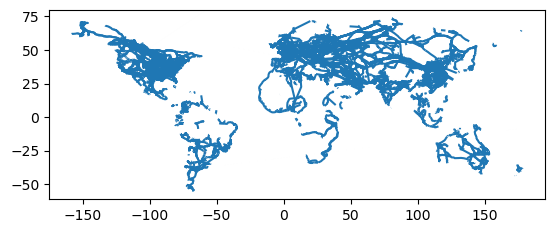

In [16]:
# Sanity-check plot of every loaded route. Pass aspect='equal' explicitly so
# matplotlib skips the geographic-aspect formula (1/cos(mean_lat)) -- with a
# CRS set, that formula trips on NaN bounds from any empty/missing geometries.
all_pipes_gdf.geometry.plot(aspect='equal')


In [17]:
geod = pyproj.Geod(ellps='WGS84')

## Per-pipeline geodetic length

In [18]:
# Pipelines with a real route -> compute geodetic length on the WGS84 ellipsoid.
all_pipes_gdf_withroute = (
    all_pipes_gdf.loc[~all_pipes_gdf.geometry.is_empty]
    .reset_index(drop=True)
    .copy()
)
all_pipes_gdf_withroute['LengthEstimateKm'] = (
    all_pipes_gdf_withroute.geometry.apply(geod.geometry_length) / 1000
)

In [19]:
# Pipelines with no route geometry but a known length -> split evenly across
# their listed countries (handled in the no-route block further down).
all_pipes_gdf_noroute = all_pipes_gdf.loc[
    all_pipes_gdf.geometry.is_empty
    & all_pipes_gdf.LengthKnownKm.notnull()
    & (all_pipes_gdf.LengthKnownKm > 0)
].copy()

### Export per-pipeline results

In [20]:
all_pipes_gdf_withroute[['ProjectID', 'LengthEstimateKm']].to_excel(
    'estimate-length-results-by-pipeline.xlsx', index=False
)

## Per-country length

In [21]:
# --- per-country length via spatial overlay ----------------------------
# Build a clean countries frame keyed by the EEZ index ('UNION' name was lost
# during the HK/Macao concat in older versions, so derive from .index directly).
countries_gdf = (
    eez_and_land_boundaries_gdf[['geometry']]
    .assign(country=lambda d: d.index.astype(str))
    .reset_index(drop=True)
)
if countries_gdf.crs is None:
    countries_gdf = countries_gdf.set_crs('EPSG:4326')

pipes_for_overlay = all_pipes_gdf_withroute[[
    'ProjectID', 'PipelineName', 'SegmentName', 'Status', 'Fuel',
    'LengthKnownKm', 'LengthEstimateKm', 'geometry',
]].copy()

print(f"overlaying {len(pipes_for_overlay)} pipelines against {len(countries_gdf)} country/EEZ polygons...")
intersected = gpd.overlay(
    pipes_for_overlay, countries_gdf, how='intersection', keep_geom_type=False
)

intersected['length_per_country'] = intersected.geometry.apply(geod.geometry_length) / 1000
intersected['length_per_country_fract'] = intersected['length_per_country'] / intersected['LengthEstimateKm']

results_by_country = (
    intersected.rename(columns={
        'PipelineName': 'pipeline_name',
        'SegmentName':  'segment_name',
        'ProjectID':    'project_id',
        'Status':       'status',
        'Fuel':         'fuel',
        'LengthEstimateKm': 'length',
    })[[
        'pipeline_name', 'segment_name', 'project_id', 'country',
        'length_per_country', 'length_per_country_fract',
        'status', 'fuel', 'length',
    ]]
    .reset_index(drop=True)
)

# Diagnostic: how much of each pipeline lies outside every EEZ/land polygon
# (international waters or unmapped area). Equivalent to the old
# `international`/`remainders` outputs, but accumulated correctly.
intersected_per_pipeline = results_by_country.groupby('project_id')['length_per_country'].sum()
international = (
    all_pipes_gdf_withroute[['ProjectID', 'PipelineName', 'LengthEstimateKm']]
    .assign(intersected_km=lambda d: d['ProjectID'].map(intersected_per_pipeline).fillna(0))
    .assign(international_km=lambda d: (d['LengthEstimateKm'] - d['intersected_km']).clip(lower=0))
    .query('international_km > 0.01')
    .reset_index(drop=True)
)
print(f"{len(international)} pipelines have >10m of route outside any EEZ/land polygon")

overlaying 5219 pipelines against 330 country/EEZ polygons...
0 pipelines have >10m of route outside any EEZ/land polygon


### No-route fallback: split known length evenly across listed countries

In [22]:
# For each pipeline with no route but a known length, divide its length evenly
# across the countries listed in CountriesOrAreas. Handled with .explode for clarity.
def _split_countries(row):
    if row['NumberOfCountries'] > 1:
        return [c.strip() for c in row['CountriesOrAreas'].split(',')]
    return [row['CountriesOrAreas']]

noroute = all_pipes_gdf_noroute[[
    'PipelineName', 'SegmentName', 'ProjectID', 'Status', 'Fuel',
    'LengthKnownKm', 'NumberOfCountries', 'CountriesOrAreas',
]].copy()
noroute['country'] = noroute.apply(_split_countries, axis=1)

results_by_country_noroute = (
    noroute.explode('country', ignore_index=True)
    .assign(n=lambda d: d.groupby('ProjectID')['country'].transform('count'))
    .assign(
        length_per_country=lambda d: d['LengthKnownKm'] / d['n'],
        length_per_country_fract=lambda d: 1 / d['n'],
    )
    .rename(columns={
        'PipelineName': 'pipeline_name',
        'SegmentName':  'segment_name',
        'ProjectID':    'project_id',
        'Status':       'status',
        'Fuel':         'fuel',
        'LengthKnownKm': 'length',
    })[[
        'pipeline_name', 'segment_name', 'project_id', 'country',
        'length_per_country', 'length_per_country_fract',
        'status', 'fuel', 'length',
    ]]
)

In [23]:
results_by_country_combined = pd.concat(
    [results_by_country, results_by_country_noroute], axis=0, ignore_index=True, sort=False
)

## Clean and export per-country results

In [24]:
results_by_country_combined = (
    results_by_country_combined[[
        'pipeline_name', 'segment_name', 'project_id', 'country',
        'length_per_country', 'length_per_country_fract',
    ]]
    .rename(columns={
        'pipeline_name': 'PipelineName',
        'segment_name':  'SegmentName',
        'project_id':    'ProjectID',
        'country':       'Country',
        'length_per_country':       'LengthEstimateKmByCountry',
        'length_per_country_fract': 'LengthPerCountryFraction',
    })
)

# Country-name remaps. Alaska / Senkaku are always-safe global aliases.
results_by_country_combined = results_by_country_combined.replace({
    'Country': {
        'Alaska': 'United States',
        'Senkaku Islands': 'Japan',
    }
})

# The Canary Islands EEZ is only intentionally crossed by the Nigeria-Morocco
# Pipeline, so the remap is masked rather than global -- otherwise any future
# pipeline that clips the Canaries would be silently relabelled.
nigeria_morocco_canary_mask = (
    results_by_country_combined['PipelineName'].str.contains('Nigeria-Morocco', case=False, na=False)
    & (results_by_country_combined['Country'] == 'Canary Islands')
)
results_by_country_combined.loc[nigeria_morocco_canary_mask, 'Country'] = 'Morocco'

results_by_country_combined = results_by_country_combined.sort_values('ProjectID')
results_by_country_combined.to_excel('estimate-length-results-by-country.xlsx', index=False)